In [73]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import null_space
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
import Bichan_code as RRRR

In [74]:
# J neural interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

# N neural interpPSTH
file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

# J neural mean firing rates
file_path = os.path.join(base_path, 'J_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_FR = pickle.load(input_file)
del input_file

# N neural mean firing rates
file_path = os.path.join(base_path, 'N_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    N_pickle_FR = pickle.load(input_file)
del input_file

# J muscle interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

# N muscle interpPSTH
ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# J muscle mean firing rates
file_path = os.path.join(base_path, 'muscle_J_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_m_FR = pickle.load(input_file)
del input_file

# N msucle mean firing rates
ile_path = os.path.join(base_path, 'muscle_N_FR.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m_FR = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

# INTER P PSTH
J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']

N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

# MEAN FR
J_all_FR = J_pickle_FR['J_all_FR']['mean_FR']
J_M1_FR = J_pickle_FR['J_M1_FR']['mean_FR']
J_PMd_FR = J_pickle_FR['J_PMd_FR']['mean_FR']
J_idx = np.r_[0:18, 36:45]
J_ntm_FR = J_all_FR[J_idx, :, :]
J_mus_FR = J_pickle_m_FR['mean_FR']

N_all_FR = N_pickle_FR['N_all_FR']['mean_FR']
N_M1_FR = N_pickle_FR['N_M1_FR']['mean_FR']
N_PMd_FR = N_pickle_FR['N_PMd_FR']['mean_FR']
N_mus_FR = N_pickle_m_FR['mean_FR']


<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:27: SyntaxWarning: invalid escape sequence '\J'
<>:3: SyntaxWarning: invalid escape sequence '\J'
<>:27: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_33452\229238616.py:3: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_33452\229238616.py:27: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


In [75]:
def red_rank (tensor_N, tensor_M, rank, pm = False, prep = False): 
    """
    Running reduced rank regression 
    """

    if pm: 
    # splicing preparatory and movement bins and scaling frmo 0 to 1 and mean centering

        N_prep_start = 30
        N_prep_end = 81     # 81 because it will get spliced off otherwise

        # retrieving dataset specifications
        J, PMd = pcar.ident(tensor_N)

        # altering movement periods depending on dataset
        if J:
            N_move_start = 150
            N_move_end = 216
        else:
            N_move_start = 142
            N_move_end = 208
        
        N_idx = np.r_[N_prep_start:N_prep_end, N_move_start:N_move_end]
        N_cut = tensor_N[:,:, N_idx]

        if PMd:
            M_prep_start = N_prep_start
            M_prep_end = N_prep_end
            M_move_start = N_move_start
            M_move_end = N_move_end
        else:
            M_prep_start = N_prep_start + 5
            M_prep_end = N_prep_end + 5
            M_move_start = N_move_start + 5
            M_move_end = N_move_end + 5
        M_idx = np.r_[M_prep_start:M_prep_end, M_move_start:M_move_end]
        M_cut = tensor_M[:,:, M_idx]

        N_cut_scale = pcar.scaling(N_cut, tuning = False)
        M_cut_scale = pcar.scaling(M_cut, tuning = False)

        # finding W_ls 
        cov = N_cut_scale.T @ N_cut_scale
        W_LS = np.linalg.solve(cov, N_cut_scale.T @ M_cut_scale)
    
        # running PCA on Neu_move @ W
        pre_PCA = W_LS.T @ N_cut_scale.T @ N_cut_scale @ W_LS
    elif prep: 
        N_prep_start = 30
        N_prep_end = 81     # 81 because it will get spliced off otherwise

        # retrieving dataset specifications
        J, PMd = pcar.ident(tensor_N)
        
        N_idx = np.r_[N_prep_start:N_prep_end]
        N_cut = tensor_N[:,:, N_idx]

        if PMd:
            M_prep_start = N_prep_start
            M_prep_end = N_prep_end
        else:
            M_prep_start = N_prep_start + 5
            M_prep_end = N_prep_end + 5
            
        M_idx = np.r_[M_prep_start:M_prep_end]
        M_cut = tensor_M[:,:, M_idx]

        N_cut_scale = pcar.scaling(N_cut, tuning = False)
        M_cut_scale = pcar.scaling(M_cut, tuning = False)

        # finding W_ls 
        cov = N_cut_scale.T @ N_cut_scale
        W_LS = np.linalg.solve(cov, N_cut_scale.T @ M_cut_scale)
    
        # running PCA on Neu_move @ W
        pre_PCA = W_LS.T @ N_cut_scale.T @ N_cut_scale @ W_LS
        
    else: 
        Neu_pm, Neu_move, M_move = pcar.time_shift(tensor_N, tensor_M)

        # finding W_ls 
        cov = Neu_move.T @ Neu_move
        W_LS = np.linalg.solve(cov, Neu_move.T @ M_move)
        
        
        # running PCA on Neu_move @ W
        pre_PCA = W_LS.T @ Neu_move.T @ Neu_move @ W_LS


     
    U, S_, V_T = np.linalg.svd(pre_PCA)
    V_rank = V_T.T[:,:rank]
    
    W_RRR = W_LS @ V_rank @ V_rank.T
    U_RRR = W_LS @ V_rank

    return W_RRR, V_rank, W_LS, U_RRR



In [76]:
rank = 3
tensor_N = N_all_tensor
tensor_M = N_mus_tensor

cond = tensor_N.shape[0]

regress_N, Neu_move, regress_M = pcar.time_shift(tensor_N, tensor_M)

time = int(Neu_move.shape[0] / cond)

Regress_N, move_N, regress_M = pcar.time_shift(tensor_N, tensor_M)
J, PMd = pcar.ident(tensor_N)

# lengths of conditions x time, regress M only has movement, whereas regress_N has prep and movement
time_ct = regress_M.shape [0]
time_ct_neu = regress_N.shape [0]

# how many time bins are included in the movement period for a single condition
time_bins = int(time_ct / cond)

# how many time bins are included in the preparatory and movement period per condition
time_bins_pm = int(time_ct_neu / cond)

# difference in bins = just prep bins ie where the movement period starts for each condition
diff_bin = int((time_bins_pm - time_bins))

# isolating the preparatory and movement bins
N_tilde_tens = pcar.shape_tensor(regress_N, cond, time_bins = time_bins_pm)
N_tilde_tens_move = N_tilde_tens[:,:,diff_bin:]
N_tilde_tens_prep = N_tilde_tens[:,:,:diff_bin]

# reshape into matrices for tuning computation
neu_move = pcar.shape_matrix(N_tilde_tens_move)
# neu_move_2 = pcar.shape_matrix(N_tilde_tens_move)
neu_prep = pcar.shape_matrix(N_tilde_tens_prep)

lam, _, _ = pcar.best_lam(neu_move, regress_M, time)
print(lam)

W_RRR, U_RRR, V_rank = RRRR.svd_RRR(neu_move, regress_M, rank, lam)

print(W_RRR.shape)

U, S, V = np.linalg.svd(W_RRR)
M_hat = neu_move @ W_RRR

# print(sum(S[:3]))
W_potent = U[:,:rank]

# W_potent = U[:, :rank]

# W_null = null_space(W_RRR.T)[:,:rank]

W_null = U[:, rank:rank*2]


move_pot = neu_move @  W_potent 
move_null = neu_move @ W_null
prep_null = neu_prep @ W_null
prep_pot = neu_prep @ W_potent
prep_null_full = neu_prep @ U[:, rank:]

var_prep_null_full = np.sum(np.var(prep_null_full, axis = 0))
var_prep_null = np.sum(np.var(prep_null, axis = 0))
var_prep_pot = np.sum(np.var(prep_pot, axis = 0))
var_full = np.sum(np.var(neu_prep, axis = 0))

print("move null ", np.sum(np.var(move_null, axis = 0)))
print("move pot ", np.sum(np.var(move_pot, axis = 0)))
print("move total variance ", np.sum(np.var(neu_move, axis = 0)))
print("prep null ", np.sum(np.var(prep_null, axis = 0)))
print("prep pot ", np.sum(np.var(prep_pot, axis = 0)))
print("prep_null full ", np.sum(np.var(prep_null_full, axis = 0)))
print("prep total variance", np.sum(np.var(neu_prep, axis = 0)))

print("null 3 frac: ", var_prep_null / var_full)
print("pot 3 frac: ", var_prep_pot / var_full)
print("null full frac: ", var_prep_null_full / var_full)



check = W_potent.T @ W_null
R2_total = 1 - np.sum((regress_M - M_hat)**2) / np.sum((regress_M - regress_M.mean(axis=0))**2)
print(np.sum(check, axis = 1))
print("R2: ", R2_total)

4.124626382901356
(275, 12)
move null  0.027094991243576148
move pot  0.6334775841455824
move total variance  7.521310130257078
prep null  0.07812612438016456
prep pot  0.02025304534570173
prep_null full  2.267917853158596
prep total variance 2.2881708985042986
null 3 frac:  0.03414348309002314
pot 3 frac:  0.008851194357440903
null full frac:  0.9911488056425587
[-1.09287579e-16 -6.35776154e-16  6.50521303e-18]
R2:  0.9357286694694099


In [77]:
# check coupling: can potent activity predict null activity during movement?
# using least squares to be consistent with your RRR approach

prep_pot  = neu_prep @ W_potent    # [ct_prep, 3]
prep_null = neu_prep @ W_null  # [ct_prep, 3]
move_pot  = neu_move @ W_potent    # [ct_move, 3]
move_null = neu_move @ W_null   # [ct_move, 3]

# OLS: W_couple solves null = potent @ W_couple
def ols_r2(X, Y):
    # solve X @ W = Y
    W_couple = np.linalg.solve(X.T @ X, X.T @ Y)
    Y_hat = X @ W_couple
    R2 = 1 - np.sum((Y - Y_hat)**2) / np.sum((Y - Y_hat.mean(axis=0))**2)
    return R2, W_couple

# check during movement - this is your training period
R2_move, W_couple_move = ols_r2(move_pot, move_null)

# check during prep - does the same coupling hold?
R2_prep, W_couple_prep = ols_r2(prep_pot, prep_null)

# check if the movement-derived coupling predicts prep null
prep_null_hat = prep_pot @ W_couple_move
R2_transfer = 1 - np.sum((prep_null - prep_null_hat)**2) / np.sum((prep_null - prep_null.mean(axis=0))**2)

print("Coupling R2 during movement:", R2_move)
print("Coupling R2 during prep:    ", R2_prep)
print("Transfer R2 move->prep:     ", R2_transfer)

# what each time period predicts through the movement communication channel
comm_move = neu_move @ W_RRR    # [ct_move, 32] - movement neural through channel
comm_prep = neu_prep @ W_RRR    # [ct_prep, 32] - prep neural through same channel

# compare the magnitude of predicted output
var_comm_move = np.sum(np.var(comm_move, axis=0))
var_comm_prep = np.sum(np.var(comm_prep, axis=0))

print("Variance communicated during movement:", var_comm_move)
print("Variance communicated during prep:    ", var_comm_prep)
print("Ratio prep/move:                      ", var_comm_prep / var_comm_move)

Coupling R2 during movement: 0.08209749702175628
Coupling R2 during prep:     0.1722668939517097
Transfer R2 move->prep:      -0.37116869562488475
Variance communicated during movement: 0.5902855214493177
Variance communicated during prep:     0.013616535552163682
Ratio prep/move:                       0.023067710552566564


In [78]:
# N_prep_proj = neu_prep @ W_null
# U, S, V = np.linalg.svd(N_prep_proj)
# print(neu_prep.shape)
# print(W_null.shape)
# print(N_prep_proj.shape)
# W_null = W_null @ V.T[:, :rank]

In [79]:
 # movement null and potent space for gamma
N_null_move = neu_move @ W_null
# N_nm_tensor = shape_tensor(N_null_move, cond)
# N_null_move = N_null_move - N_null_move.mean(axis=0)     # the other one to comment out
# N_null_move = shape_matrix(N_nm_tensor)
null_move_frob = np.linalg.norm(N_null_move)**2
null_move_var = np.sum(np.var(N_null_move, axis=0))

N_pot_move = neu_move @ W_potent
# N_pm_tensor = shape_tensor(N_pot_move, cond)
# N_pot_move = N_pot_move - N_pot_move.mean(axis=0)     # the one to comment out
# N_pot_move = shape_matrix(N_pm_tensor)
pot_move_frob = np.linalg.norm(N_pot_move)**2
pot_move_var = np.sum(np.var(N_pot_move, axis=0))

# computing gamma which is a scaling factor
gamma = null_move_var / pot_move_var
gamma2 = null_move_frob / pot_move_frob

# Null and potent projections of movement neural data
N_null_prep = neu_prep @ W_null
# N_np_tensor = shape_tensor(N_null_prep, cond)
N_null_prep = N_null_prep - N_null_prep.mean(axis=0) 
# N_null_prep = shape_matrix(N_np_tensor)       # subtract columns for variance
null_prep_frob = np.linalg.norm(N_null_prep)**2
null_prep_var = np.sum(np.var(N_null_prep, axis=0))

N_pot_prep = neu_prep @ W_potent
# N_pp_tensor = shape_tensor(N_pot_prep, cond)
N_pot_prep = N_pot_prep - N_pot_prep.mean(axis=0) 
# N_pot_prep = shape_matrix(N_pp_tensor)       # subtract columns for variance
pot_prep_frob = np.linalg.norm(N_pot_prep)**2
pot_prep_var = np.sum(np.var(N_pot_prep, axis=0))

# tuning ratio
var_tuning = (null_prep_var / pot_prep_var) * ( 1/ gamma2 )   # this is with using the sum of variance
no_gamma_tuning = (null_prep_var / pot_prep_var)    # this is with using the frobenius norm and not variance on the movement data

# fraction of prep in null space and potent space
null_fraction = null_prep_var / (null_prep_var + pot_prep_var)
pot_fraction  = pot_prep_var / (null_prep_var + pot_prep_var)


var_total  = np.sum(np.var(neu_prep, axis=0))
var_null   = np.sum(np.var(N_null_prep, axis=0))
var_potent = np.sum(np.var(N_pot_prep, axis=0))

frac_null   = var_null / var_total
frac_potent = var_potent / var_total


var_move_tot = np.sum(np.var(neu_move, axis=0))
var_null_move   = np.sum(np.var(N_null_move, axis=0))
var_potent_move = np.sum(np.var(N_pot_move, axis=0))

frac_null_move   = var_null_move / var_move_tot
frac_potent_move = var_potent_move / var_move_tot


# per-dimension variance during movement
# null_move_perdim = null_move_var / (202 - rank)   # 5.892 / 199 = 0.0296
# pot_move_perdim  = pot_move_var  / rank            # 0.057 / 3   = 0.0191

# gamma_perdim = null_move_perdim / pot_move_perdim  # 0.0296 / 0.0191 = 1.55


# tuning_perdim = (null_prep_var / pot_prep_var) * (1 / gamma_perdim)


print("frac null prep: ", frac_null)
print("frac potent prep: ", frac_potent)
print("frac null move: ", frac_null_move)
print("frac potent move: ", frac_potent_move)


print("potent move variance: ", pot_move_var)
print("null move variance: ", null_move_var)
print("null prep variance:", null_prep_var)
print("potent prep variance: ", pot_prep_var)
print("Tuning with variance: ", var_tuning)
print("Tuning with no gamma: ", no_gamma_tuning)
print("Prep fraction: ",  null_fraction)
print("1/gamma :", 1/gamma2)

frac null prep:  0.034143483090023116
frac potent prep:  0.008851194357440901
frac null move:  0.0036024297328968195
frac potent move:  0.08422436692208704
potent move variance:  0.6334775841455824
null move variance:  0.027094991243576148
null prep variance: 0.07812612438016452
potent prep variance:  0.020253045345701725
Tuning with variance:  56.52568884226724
Tuning with no gamma:  3.857500096732125
Prep fraction:  0.7941327884537257
1/gamma : 14.653451049852958


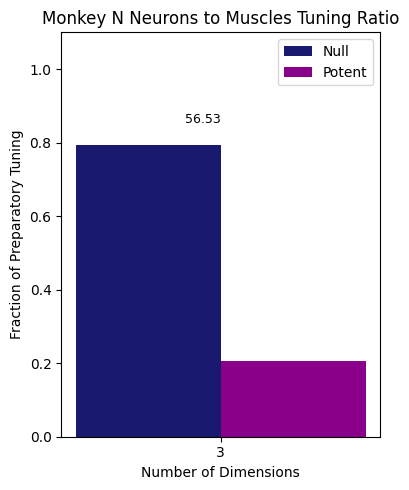

In [80]:
null_prop = null_fraction
potent_prop = (1 - null_fraction)   # ensures they sum to 1
dims = rank
var_tuning = var_tuning


x = 0             # group positions
width = 0.35                       # bar width
y_val = np.maximum(float(null_prop), float(potent_prop)) + 0.05
fig, ax = plt.subplots(figsize=(4, 5))

# Null bars (all same color)
ax.bar(x - width/2, null_prop, width, label="Null", color='midnightblue')

# Potent bars (all same color)
ax.bar(x + width/2, potent_prop, width, label="Potent", color='darkmagenta')


ax.text(
x,                      # center of the two bars
y_val,  # above taller bar
f"{var_tuning:.2f}",     # <-- put whatever value you want here
ha='right',
va='bottom',
fontsize=9
)      
ax.set_xticks([x])
ax.set_xticklabels([dims])
ax.set_xlabel("Number of Dimensions")
ax.set_ylabel("Fraction of Preparatory Tuning")
ax.set_ylim(0, 1.1)
ax.legend()
if J:
    J_text = "J"
else:
    J_text = "N"
if PMd:
    an_text = "PMd to M1"
else:
    an_text = "Neurons to Muscles"
title_text = f"Monkey {J_text} {an_text} Tuning Ratio"


ax.set_title(title_text)
plt.tight_layout()
plt.show()

frac null:  0.009788732448989125
frac potent:  0.04346811616143615


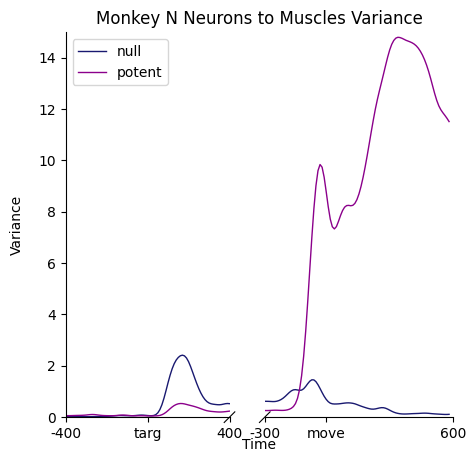

In [81]:
fig_4D = False
N_fig4, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True) 

# projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
N_potent = N_fig4 @ W_potent
N_null = N_fig4 @ W_null

# mean centering
N_potent = N_potent - np.mean(N_potent, axis = 0)
N_null = N_null - np.mean(N_null, axis = 0)

# reshaping into a tensor
pot_tensor = pcar.shape_tensor(N_potent, cond)
null_tensor = pcar.shape_tensor(N_null, cond)
_, _, time = pot_tensor.shape

# initializing array for holding the variance
V_pot = np.zeros(time)
V_null = np.zeros(time)

var_total  = np.sum(np.var(N_fig4, axis=0))
var_null   = np.sum(np.var(N_null, axis=0))
var_potent = np.sum(np.var(N_potent, axis=0))

frac_null   = var_null / var_total
frac_potent = var_potent / var_total
print("frac null: ", frac_null)
print("frac potent: ", frac_potent)


# goes through all time steps and pulls all conditions
for t in range (time):
    X_pot  = pot_tensor[:, :, t]
    X_null = null_tensor[:, :, t]
    
    # variance 
    V_null[t] = np.sum(np.var(X_null, axis=0))
    V_pot[t]  = np.sum(np.var(X_pot, axis=0))
    
    # # squaring and adding values and dividing by condition numbers to compute variance
    # V_null[t] = np.sum(X_null**2) / (cond * dims)
    # V_pot[t]  = np.sum(X_pot**2)  / (cond * dims)

V_null = (1/gamma2) * V_null
V_pot = (1/gamma) * V_pot

# initializing figure parameters
fig = plt.figure(figsize=(5, 5))
gs = GridSpec(1, 1, figure=fig)

# time for plotting x axis and indexes needed for correct slicing
prep_time = np.arange(0, 810, 10)
prep_idx = np.arange(81)
move_idx_start = len(prep_idx)
move_end_4D = move_idx_start + 30

if fig_4D:
    max = np.max(np.abs(np.concatenate([V_null[:move_end_4D], V_pot[:move_end_4D]])))
else:
    max = np.max(np.abs(np.concatenate([V_null, V_pot])))
    
# different limits on the axes depending on which dataset was given
if J:
    J_text = "J"
    if fig_4D:
        move_time = np.arange(-300, 0, 10)
        bax1 = brokenaxes(
            xlims=((0, 800), (-300, 0)),
            ylims=((0, max + .2),),
            hspace=.05,
            subplot_spec=gs[0])
    else:
        bax1 = brokenaxes(xlims=((0, 800), (1250, 2170)), ylims=((0, max + .2),), hspace=.05, subplot_spec=gs[0])
        move_time = np.arange(1250, 2160, 10)
    
else:
    J_text = "N"
    if fig_4D:
        move_time = np.arange(-300, 0, 10)
        bax1 = brokenaxes(
        xlims=((0, 800), (-300, 0)),
        ylims=((0, max + .2),),
        hspace=.05,
        subplot_spec=gs[0])
    else:
        bax1 = brokenaxes(xlims=((0, 800), (1170, 2090)), ylims=((0, max + .2),), hspace=.05, subplot_spec=gs[0])
        move_time = np.arange(1170, 2080, 10)
        
if fig_4D:
    # plotting data
    move_end = move_idx_start + 30
    bax1.plot(prep_time, V_null[prep_idx], '-', color='midnightblue', label = 'null', linewidth = 1)
    bax1.plot(move_time, V_null[move_idx_start:move_end], '-', color='midnightblue',  linewidth = 1)
    bax1.plot(prep_time, V_pot[prep_idx], '-', color='darkmagenta', label = 'potent',  linewidth = 1)
    bax1.plot(move_time, V_pot[move_idx_start:move_end], '-', color='darkmagenta',  linewidth = 1)
else:
# plotting data
    bax1.plot(prep_time, V_null[prep_idx], '-', color='midnightblue', label = 'null', linewidth = 1)
    bax1.plot(move_time, V_null[move_idx_start:], '-', color='midnightblue',  linewidth = 1)
    bax1.plot(prep_time, V_pot[prep_idx], '-', color='darkmagenta', label = 'potent',  linewidth = 1)
    bax1.plot(move_time, V_pot[move_idx_start:], '-', color='darkmagenta',  linewidth = 1)

if J:
    # preparatory ticks
    bax1.axs[0].set_xticks([0, 400, 800])
    bax1.axs[0].set_xticklabels(['-400', 'targ', '400'])
    if fig_4D:
        # movement ticks
        bax1.axs[1].set_xticks([-300, 0])
        bax1.axs[1].set_xticklabels(['-300', 'move'])
    else:
        # movement ticks
        bax1.axs[1].set_xticks([1250, 1550, 2170])
        bax1.axs[1].set_xticklabels(['-300', 'move', '600'])
else:
    # preparatory ticks
    bax1.axs[0].set_xticks([0, 400, 800])
    bax1.axs[0].set_xticklabels(['-400', 'targ', '400'])
    if fig_4D:
        # movement ticks
        bax1.axs[1].set_xticks([-300, 0])
        bax1.axs[1].set_xticklabels(['-300', 'move'])
    else:
        # movement ticks
        bax1.axs[1].set_xticks([1170, 1470, 2090])
        bax1.axs[1].set_xticklabels(['-300', 'move', '600'])

# sets titles and legend  
bax1.set_ylabel("Variance")
if PMd:
    an_text = "PMd to M1"
else:
    an_text = "Neurons to Muscles"
title_text = f"Monkey {J_text} {an_text} Variance"
if fig_4D:
    title_text = f"Monkey {J_text} {an_text} Tuning"
    bax1.set_ylabel("tuning")
bax1.set_title(title_text)
bax1.set_xlabel("Time")

bax1.legend(loc = 2)


3603.493159356778
3603.493159356778
3603.493159356778
3603.493159356778


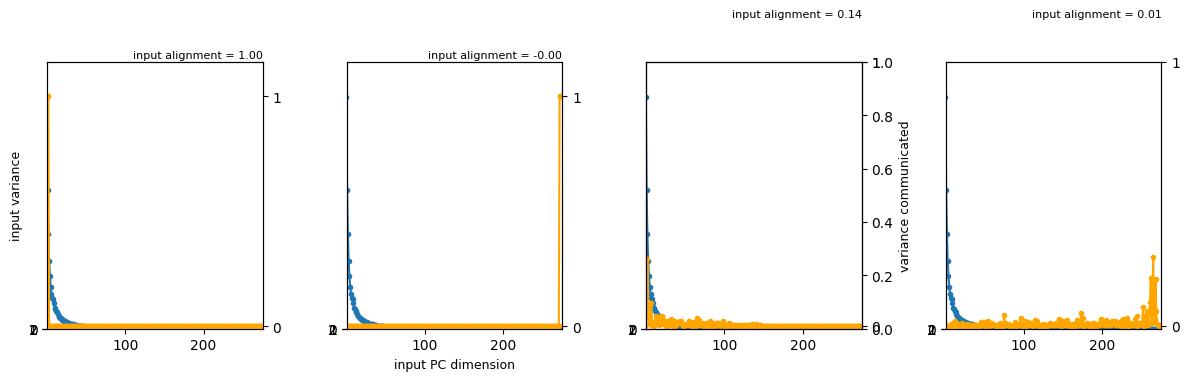

In [82]:
# Parameters
T = 1000   # number of time points
nx = tensor_N.shape[1]
ny = 15
r = 3      # rank of the communication subspace

# # Generate input with fixed eigenvalues
# basis, _ = np.linalg.qr(np.random.randn(nx, nx))  # random orthogonal basis

# # create exponential decay eigenvalues
# n_samples = 20
# tmp = np.linspace(0, 1, n_samples)  # normalized time from 0 to 1
# start_val = 2
# end_val = 1
# s = end_val + (start_val - end_val) * np.exp(-3 * tmp)  # adjust -3 for steepness

cov_N = neu_move.T @ neu_move  # covariance of input

# X = multivariate_normal.rvs(mean=np.zeros(nx), cov=cov_X, size=T)
# Input main axes (PCA on covariance)
Upca, Spcavec, _ = np.linalg.svd(cov_N)
# Spcavec = Spcavec.tolist()  # convert once, use everywhere
# Communication weights
Ws = [
    Upca[:, :r],           # top r PCs
    Upca[:, -r:],          # bottom r PCs
    W_RRR,  # random weights
    W_null
]
from Bichan_code import alignment_input
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ii in range(4):
    # Pick weight vector
    W = Ws[ii]
    W = W / np.linalg.norm(W,ord=2)  # normalize weight (magnitude does not affect alignment)

    # SVD of weights
    Uw, Swvec, Vw_T = np.linalg.svd(W)
    # Swvec = np.diag(np.diag(np.diag(np.atleast_2d(Swvec)))) if W.ndim > 1 else Swvec

    # Communicated variance
    var_comm = np.diag(Upca.T @ W @ W.T @ Upca)

    # Alignment index
    a_in, _, _ = alignment_input(regress_N, W, r, cov_N)

    # -------- Make plot --------------
    ax = axes[ii]
    ax2 = ax.twinx()

    ax.plot(Spcavec, "o-", markersize=3, label="Input variance")
    ax2.plot(var_comm, "o-", markersize=3, color="orange", label="Communicated variance")

    ax.set_ylim([-0.01, float(Spcavec[0]) * 1.15])
    print(float(Spcavec[0]))
    ax2.set_ylim([-0.01, float(np.max(var_comm)) * 1.15])

    ax.set_xlim([0.5, nx + 0.5])
    ax.set_yticks([0, 1, 2])
    ax2.set_yticks([0, 1])

    ax2.text(nx + 0.5, 1.2,
             f"input alignment = {a_in:.2f}",
             ha="right", va="top",
             fontsize=8, fontweight="normal")

# Axis labels
axes[0].set_ylabel("input variance", fontsize=9)       # MATLAB ax(1).YAxis(1).Label
axes[2].right_ax = axes[2].twinx()  # ensure right axis exists
axes[2].right_ax.set_ylabel("variance communicated", fontsize=9)

# X-axis label
axes[1].set_xlabel("input PC dimension", fontsize=9)

# Figure size in inches (MATLAB [0 0 7
plt.tight_layout()
plt.show()

In [83]:
tensor_N = N_all_tensor
tensor_M = N_mus_tensor
dimensions = 3
# retrieving number of conditions
cond = tensor_N.shape[0]

# retrieving dataset specifications
J, PMd = pcar.ident(tensor_N)

# tensor_N = slice(tensor_N)

if PMd: 
    tensor_M = slice(tensor_M)

# scaling, mean centering, and involving only the time periods needed for regression (the movement)
regress_N, move_N, regress_M = pcar.time_shift(tensor_N, tensor_M)
time_ct = regress_M.shape [0]
time_ct_neu = regress_N.shape [0]

# retrieving data projected onto the first N_dim and M_dim PCs
N_tilde,N_PCs = pcar.run_PCA(regress_N, dimensions)
M_tilde,PCs = pcar.run_PCA(regress_M, int(dimensions/2))

# how many time bins are included in the movement period
time_bins = int(time_ct / cond)

# how many time bins are included in the preparatory and movement period
time_bins_pm = int(time_ct_neu / cond)

# difference in bins = prep bins
diff_bin = int((time_bins_pm - time_bins))

# removing prep bins adn reshaping for ridge
regress_N = pcar.shape_tensor(N_tilde, conditions = cond, time_bins = time_bins_pm)
N_tens_spliced = regress_N[:,:, diff_bin:]
regress_N_sp = pcar.shape_matrix(N_tens_spliced)

# running through ridge regression
W, R2_total, R2_dim, MSE_all, RMSE_all = pcar.r_regress(regress_N_sp, M_tilde, num_bins = time_bins, J = J, PMd = PMd, cv = True)
print(R2_total)

[21 13 26  0  2 19 17 16  5  7 11  9 18 23  8  6  3  4 12 25 22 14]
>>> best_lam returning: 4.124626382901356
0.7776272655931596


In [84]:
tensor_N = J_ntm_tensor
tensor_M = J_mus_tensor

In [85]:
# Use all 108 neural conditions for PCA to get a better neural manifold
N_full_tensor = J_all_tensor  # all 108 conditions

# But for the regression N->M, use only the 27 matched conditions
N_matched_tensor = J_all_tensor[J_idx, :, :]  # 27 conditions matching muscle

# Run PCA on full 108-condition neural data
regress_N_full, _, M_split = pcar.time_shift(N_full_tensor, tensor_M)
N_tilde_full, PCs = pcar.run_PCA(regress_N_full, 6)
M_tilde, _ = pcar.run_PCA(M_split, 3)

# Project the 27 matched conditions onto those same PCs
regress_N_matched, N_move_matched, regress_M = pcar.time_shift(N_matched_tensor, tensor_M)
N_tilde_matched = regress_N_matched @ PCs


# fit W on movement only
cond = tensor_N.shape[0]
time_ct = regress_M.shape[0]
time_bins = int(time_ct / cond)
time_bins_pm = int(regress_N_matched.shape[0] / cond)
diff_bin = time_bins_pm - time_bins

N_tens = pcar.shape_tensor(N_tilde_matched, cond, time_bins_pm)
N_tilde_move = pcar.shape_matrix(N_tens[:,:,diff_bin:])
N_tilde_prep = pcar.shape_matrix(N_tens[:,:,:diff_bin])

# fit W on ALL movement data, no train/test split
C = N_tilde_matched.T @ N_tilde_matched
lam, _, _ = pcar.best_lam(N_tilde_matched, M_tilde, time_bins)
W = np.linalg.solve(C + lam * np.eye(6), N_tilde_matched.T @ M_tilde)

U, S, Vt = np.linalg.svd(W, full_matrices=True)
W_potent = U[:, :3]
W_null = U[:, 3:]

# check R2 of the regression
M_hat = N_tilde_matched @ W
R2 = 1 - np.sum((M_tilde - M_hat)**2) / np.sum((M_tilde - M_tilde.mean(axis=0))**2)
print("R2 of regression:", R2)

# check movement period potent vs null variance
N_pot_move = N_tilde_matched @ W_potent
N_null_move = N_tilde_matched @ W_null
N_pot_move -= N_pot_move.mean(axis=0)
N_null_move -= N_null_move.mean(axis=0)
print("Potent move norm^2:", np.linalg.norm(N_pot_move)**2)
print("Null move norm^2:  ", np.linalg.norm(N_null_move)**2)
print("Gamma:", np.linalg.norm(N_null_move)**2 / np.linalg.norm(N_pot_move)**2)

# check prep period
N_pot_prep = N_tilde_prep @ W_potent
N_null_prep = N_tilde_prep @ W_null
N_pot_prep -= N_pot_prep.mean(axis=0)
N_null_prep -= N_null_prep.mean(axis=0)
print("Potent prep norm^2:", np.linalg.norm(N_pot_prep)**2)
print("Null prep norm^2:  ", np.linalg.norm(N_null_prep)**2)
print("Raw prep null/pot ratio:", np.linalg.norm(N_null_prep)**2 / np.linalg.norm(N_pot_prep)**2)
print("Tuning ratio:", (np.linalg.norm(N_null_prep)**2 / np.linalg.norm(N_pot_prep)**2) / 
                       (np.linalg.norm(N_null_move)**2 / np.linalg.norm(N_pot_move)**2))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1369 is different from 2479)

In [ ]:
W = np.linalg.solve(C + lam * np.eye(6), N_tilde_move.T @ M_tilde)
print("W shape:", W.shape)
print("W singular values:", np.linalg.svd(W, compute_uv=False))
U, S, Vt = np.linalg.svd(W, full_matrices=True)
print("U shape:", U.shape)

# verify potent captures more movement variance than null
N_pot = N_tilde_move @ U[:, :3]
N_nul = N_tilde_move @ U[:, 3:]
N_pot -= N_pot.mean(axis=0)
N_nul -= N_nul.mean(axis=0)
print("Move potent norm:", np.linalg.norm(N_pot)**2)
print("Move null norm:  ", np.linalg.norm(N_nul)**2)

# now check what M_tilde looks like — is it actually varying across conditions?
print("M_tilde variance per dim:", np.var(M_tilde, axis=0))
print("M_tilde total variance:", np.sum(np.var(M_tilde, axis=0)))

# and check N_tilde_prep variance
print("N_tilde_prep total variance:", np.sum(np.var(N_tilde_prep, axis=0)))
print("N_tilde_move total variance:", np.sum(np.var(N_tilde_move, axis=0)))

NameError: name 'C' is not defined